### A notebook to create croparray objects from videos and tracking files. Can run on lists of files in batch.

In [3]:
import croparray as ca
from pathlib import Path

In [31]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Input files
DATA_DIR = Path(r"Z:\SharedInternal\Marianas_data\20260409\wt_U2OS_SA\Stacks")
CSV_FILES = sorted(DATA_DIR.glob("*_allspots.csv"))
VID_FILES = sorted(DATA_DIR.glob("*.tif"))
assert len(VID_FILES) == len(CSV_FILES), f"Mismatch: {len(VID_FILES)} videos vs {len(CSV_FILES)} csvs"

# Cropping parameters
XY_PAD = 10                         # Typically 5, but bigger if spots are > diffraction limited
Z_PAD = 1                           # Only used if tracking was also done in Z

# Physical metadata (should match TrackMate if TrackMate units not pixels)
DX = 0.074  ## pixel size
DY = 0.074 
DZ = .3      ## this is ignored if tracking was only done in 2D
DT = 1
UNITS = ["microns", "frames"]
NOTES = 'A crop array in WT U2OS cells. Imaged as fast as possible in 3 channels on the Marianas. Ch0 = 12xSunTag-KDM5B-XBP1SA-MS2 labeled with mST-tagged anti-SunTag scFv. Ch1 = dsRed-ER. Ch2 = MCP-Halo labeled with JF646. Used Sun+MCP APP. Spots were tracked in 2D on max-projected images using TrackPy.'
DATE_STR = "2026-04-09"

# Spot table handling
TRACKER = "auto"  # "trackmate" or "trackpy"; "auto" automatically determines; None for croparray
KEEP_COLS = ["MEAN_INTENSITY_CH1","TOTAL_INTENSITY_CH1", "CONTRAST_CH1", "SNR_CH1"]  # Optional; Note: sister colums are kept too (_CH2, _CH3...)

# ====================================
# PARAMETERS THAT DON'T NEED TO CHANGE
# ====================================
# Output
OUT_SUBDIR = "CropArrays"          # created inside DATA_DIR
OUT_EXT = ".nc"                    # standard is .nc, but can change

# Axis handling
AXES_SOURCE_INDEX = 0              # which video to use for axis definition; safe 0 (always there)


In [32]:
CSV_FILES, VID_FILES

([WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 1_XY1775772049.ome_allspots.csv'),
  WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 2_XY1775772050.ome_allspots.csv'),
  WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 3_XY1775772051.ome_allspots.csv'),
  WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 4_XY1775772052.ome_allspots.csv'),
  WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 5_XY1775772053.ome_allspots.csv'),
  WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 6_XY1775772054.ome_allspots.csv'),
  WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 7_XY1775772055.ome_allspots.csv'),
  WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/Z_2T  - Position 8_XY1775772056.ome_allspots

In [33]:
# Build and save croparrays. This will not overwrite existing croparrays (may need to restart kernel if you delete .nc files and try to rerun)
written = ca.build.make_croparrays(VID_FILES, CSV_FILES, out_dir=DATA_DIR/OUT_SUBDIR, out_ext=OUT_EXT, tracker=TRACKER, xy_um_per_px=DX, z_um_per_plane=DZ, define_axes=True, keep_cols=KEEP_COLS, axes_source_index=AXES_SOURCE_INDEX, xy_pad=XY_PAD, z_pad=Z_PAD, dx=DX, dy=DY, dz=DZ, dt=DT, units=UNITS, date=DATE_STR, notes=NOTES, as_object=False, skip_existing=True, progress=True)

croparray:   0%|          | 0/9 [00:00<?, ?file/s]

Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video dimensions: (1, 2, 21, 1046, 1046, 3)
Max # of spots per frame: 26
Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video dimensions: (1, 2, 21, 1046, 1046, 3)
Max # of spots per frame: 85
Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video dimensions: (1, 2, 21, 1046, 1046, 3)
Max # of spots per frame: 50
Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video dimensions: (1, 2, 21, 1046, 1046, 3)
Max # of spots per frame: 60
Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video dimensions: (1, 2, 21, 1046, 1046, 3)
Max # of spots per frame: 101
Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video dimensions: (1, 2, 21, 1046, 1046, 3)
Max # of spots per frame: 65
Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video dimensions: (1, 2, 21, 1046, 1046, 3)
Max # of spots per frame: 47
Original video dimensions: (1, 2, 21, 1024, 1024, 3)
Padded video di

Check croparrays

In [34]:
NC_DIR = DATA_DIR/OUT_SUBDIR
NC_FILES = sorted(NC_DIR.glob("*.nc"))
NC_FILES

[WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 1_XY1775772049.ome.nc'),
 WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 2_XY1775772050.ome.nc'),
 WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 3_XY1775772051.ome.nc'),
 WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 4_XY1775772052.ome.nc'),
 WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 5_XY1775772053.ome.nc'),
 WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 6_XY1775772054.ome.nc'),
 WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 7_XY1775772055.ome.nc'),
 WindowsPath('Z:/SharedInternal/Marianas_data/20260409/wt_U2OS_SA/Stacks/CropArrays/Z_2T  - Position 8_XY1775772056.om

In [35]:
# Check croparray 
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import CropArray
my_ca: CropArray = ca.io.open_croparray(NC_FILES[0], as_object=True)

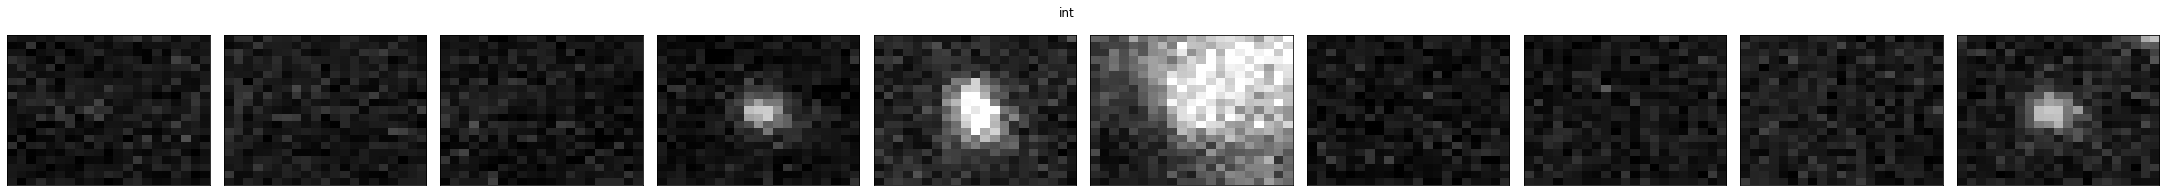

In [38]:
my_ca.isel(fov=0,z=10,ch=0).plot.plot_croparray_crops(n=(0,10,1), layer='int',t=(0,1,1), col='n');

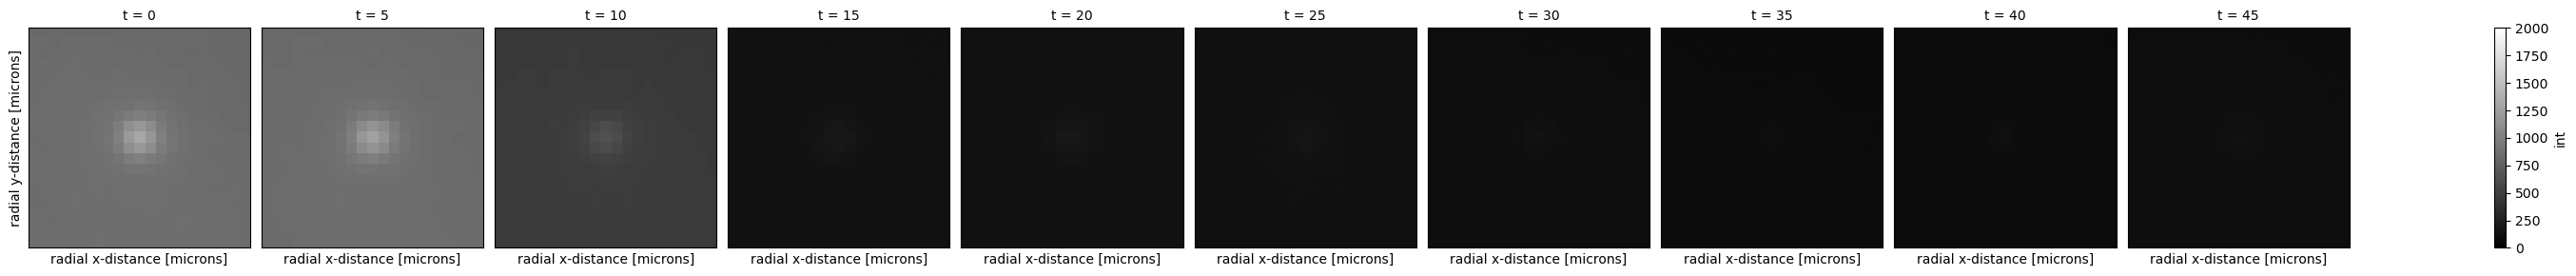

In [8]:
my_ca['int'].isel(fov=0,z=0,ch=1).mean(dim=['n']).rolling(t=5, center=True, min_periods=1).mean().isel(t=slice(None, None, 5)).plot.imshow(col="t", cmap='gray',robust=True, vmin=0,vmax=2000,xticks=[],yticks=[],)